# Phase 2b. Pan-cancer TAM subtype validation

이 노트북의 목적은 GSE154763 pan-cancer myeloid dataset을 이용하여 C1QC+ TAM, SPP1+ TAM, ISG15+ TAM이 암종별로 어떻게 나타나는지 확인하는 것이다.

본 분석은 두 가지 기준을 구분한다.

1. Annotation-based strict subtype
   - 기존 MajorCluster annotation 이름에 C1QC, SPP1, ISG15가 명시된 macrophage cluster만 해당 TAM subtype으로 매핑한다.
   - 그 외 macrophage cluster는 임의로 병합하지 않고 Other Macrophage로 유지한다.

2. Marker score-based validation
   - C1QC/SPP1/ISG15 marker gene set score를 계산하여 기존 annotation이 실제 발현 경향과 일치하는지 확인한다.
   - Other Macrophage 중 특정 subtype-like expression pattern을 보이는 cluster가 있는지도 확인한다.

In [25]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import anndata as ad
from tqdm import tqdm
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from utils.paths import *

## 1. Dataset overview

GSE154763은 8개 암종의 myeloid cell dataset으로, 각 암종별 normalized expression matrix와 metadata가 제공된다.

이 데이터는 이미 MajorCluster annotation이 포함되어 있으므로, 본 분석에서는 de novo clustering을 수행하지 않고 기존 annotation을 활용하여 macrophage subtype composition과 marker score를 재검증한다.

In [3]:
meta = pd.read_csv(LYM_META)

print(meta.shape)
print(meta.columns.tolist())
display(meta.head())

print(meta["MajorCluster"].value_counts())
print(meta["cancer"].value_counts())

(615, 14)
['index', 'batch', 'patient', 'tissue', 'percent_hsp', 'percent_mito', 'n_genes', 'n_counts', 'MajorCluster', 'source', 'tech', 'cancer', 'UMAP1', 'UMAP2']


,index,batch,patient,tissue,percent_hsp,percent_mito,n_genes,n_counts,MajorCluster,source,tech,cancer,UMAP1,UMAP2
0,AACACGTGTTTGGGCC-15,15,P20181123,T,0.006040,0.0,4789,29802.0,M02_cDC1_CLEC9A,ZhangLab,10X5,LYM,0.572999,3.933673
1,AACCGCGAGTTCGCAT-15,15,P20181123,T,0.003356,0.0,1641,5065.0,M06_Macro_ISG15,ZhangLab,10X5,LYM,5.801088,2.652734
2,AACTGGTAGCCACTAT-15,15,P20181123,T,0.000368,0.0,922,2716.0,M06_Macro_ISG15,ZhangLab,10X5,LYM,4.989789,4.353085
3,AAGGCAGTCGTCGTTC-15,15,P20181123,T,0.004203,0.0,1511,4759.0,M06_Macro_ISG15,ZhangLab,10X5,LYM,4.954624,1.894000
4,AAGGTTCAGATAGGAG-15,15,P20181123,T,0.016225,0.0,1350,3698.0,M03_cDC2_CD1C,ZhangLab,10X5,LYM,2.019562,3.539996


MajorCluster
M06_Macro_ISG15    264
M04_Mono_CD14      141
M05_Mono_CD16      121
M07_Macro_C1QC      29
M03_cDC2_CD1C       26
M01_pDC_LILRA4      22
M02_cDC1_CLEC9A     12
Name: count, dtype: int64
cancer
LYM    615
Name: count, dtype: int64


### LYM_META 확인결과

MajorCluster 확인 결과, 이전 폐암 데이터와는 다르게 LYM 데이터에서는 M06_Macro_ISG15이 264 cells로 가장 많았고,  M07_Macro_C1QC는 29 cells로 상대적으로 적게 관찰되었다.  

해당 결과값으로 알 수 있는 것
- LYM 데이터는 총 615 cells이며, 전부 lymphoma(LYM) 데이터이다.
- MajorCluster는 이미 myeloid 계열 annotation이 포함되어있다.
- macrophage 관련 cluster는 M06_Macro_ISG15와 M07_Macro_C1QC 두 개가 존재한다.
- SPP1+ TAM은 별도 cluster로 제공되지 않았기 때문에 marker expression 또는 score 기반으로 추가 확인이 필요하다. 

In [4]:
expr = pd.read_csv(LYM_NM, index_col=0, nrows=5)

print(expr.shape)
print(expr.index[:3].tolist())
print(expr.columns[:3].tolist())

(5, 11283)
['AACACGTGTTTGGGCC-15', 'AACCGCGAGTTCGCAT-15', 'AACTGGTAGCCACTAT-15']
['FO538757.2', 'LINC00115', 'NOC2L']


LYM normalized expression matrix는 cell이 row, gene이 column으로 저장되어 있다.  
따라서 AnnData 생성 시 전치(.T)는 필요하지 않다. 

## 2. Build AnnData and merge cancers

expression matrix 불러와서 AnnData로 merge 작업 진행하여 pan-cancer 데이터를 한개로 합쳐준다.  

sparse 행렬 + float32 다운캐스팅으로 메모리 절약  
- 기본값인 float64 대신 float32 사용 -> 메모리 절반으로 감소
- csr_matrix로 희소행렬 변환 -> 0이 많은 scRNA-seq 데이터에 효율적

### Q. 왜 outer/inner를 둘 다 만들었는가?

outer join은 암종별 gene set을 모두 보존하므로 metadata 기반 composition 분석에는 사용할 수 있다.  
inner join은 모든 암종에 공통으로 존재하는 gene만 남기므로 marker score처럼 gene expression을 비교하는 분석에 더 안전하다.

In [7]:
import anndata as ad
import scipy.sparse as sp

adata_list_outer = []
adata_list_inner = []

cancers = ['ESCA', 'KIDNEY', 'LYM', 'MYE', 'OV-FTC', 'PAAD', 'THCA', 'UCEC']

for cancer in tqdm(cancers, desc="Loading"):
    expr_path = CSV_DIR / f'GSE154763_{cancer}_normalized_expression.csv.gz'
    meta_path = CSV_DIR / f'GSE154763_{cancer}_metadata.csv.gz'
    
    expr = pd.read_csv(expr_path, index_col=0)
    meta = pd.read_csv(meta_path)
    
    adata = ad.AnnData(sp.csr_matrix(expr.values.astype('float32')))
    adata.obs_names = expr.index.astype(str)
    adata.var_names = expr.columns.astype(str)
    
    adata.obs = meta.set_index('index').loc[adata.obs_names].copy()
    
    adata_list_outer.append(adata)
    adata_list_inner.append(adata)
    
    del expr, meta, adata
    
    
adata_all_outer = sc.concat(
    adata_list_outer,
    join="outer",
    index_unique="-"
)

adata_all_inner = sc.concat(
    adata_list_inner,
    join="inner",
    index_unique="-"
)

print("outer:", adata_all_outer.shape)
print("inner:", adata_all_inner.shape)


adata_all_outer.write_h5ad(ALL_OUTER_H5AD)
adata_all_inner.write_h5ad(ALL_INNER_H5AD)

print("saved outer:", ALL_OUTER_H5AD)
print("saved inner:", ALL_INNER_H5AD)


Loading: 100%|██████████| 8/8 [04:24<00:00, 33.06s/it] 


outer: (65698, 18486)
inner: (65698, 11102)
saved outer: dataset\GSE154763_all_outer.h5ad
saved inner: dataset\GSE154763_all_inner.h5ad


In [8]:
# MajorCluster와 cancer 분포 확인
print(adata_all_outer.obs["cancer"].value_counts())
print(adata_all_outer.obs["MajorCluster"].value_counts())

# 유전자 손실 확인
print(f"outer: {adata_all_outer.shape}")  # 전체 유전자
print(f"inner: {adata_all_inner.shape}")  # 공통 유전자
print(f"유전자 손실: {adata_all_outer.shape[1] - adata_all_inner.shape[1]}개")

cancer
KIDNEY    28930
UCEC       8808
ESCA       7673
MYE        7619
THCA       5312
OV-FTC     3888
PAAD       2853
LYM         615
Name: count, dtype: int64
MajorCluster
M07_Mono_CD16        11093
M06_Mono_CD14         9058
M04_cDC2_CD1C         7702
M09_Macro_C1QC        3953
M08_Macro_NLRP3       3903
M01_Mast_KIT          3868
M11_Macro_C1QC        2401
M09_Macro_IL1B        2363
M05_Mono_CD14         2321
M10_Macro_GPNMB       2264
M12_Macro_LYVE1       2202
M08_Macro_SPP1        1709
M06_Mono_CD14CD16     1608
M10_Macro_C1QC        1544
M08_Macro_FN1         1319
M11_Macro_LYVE1       1217
M13_Macro_INHBA       1100
M10_Macro_SPP1        1072
M09_Macro_INHBA        947
M05_cDC3_LAMP3         734
M02_pDC_LILRA4         675
M03_cDC1_CLEC9A        619
M09_Macro_SPP1         498
M03_cDC2_CD1C          340
M09_Macro_ISG15        318
M06_Macro_ISG15        264
M11_Macro_ISG15        144
M04_Mono_CD14          141
M05_Mono_CD16          121
M01_pDC_LILRA4         111
M02_cDC1_CLEC9A 

Merge 후 cancer별 cell 수와 MajorCluster 분포를 확인하였다. KIDNEY cell 수가 가장 많고 LYM은 상대적으로 작으므로, 이후 pan-cancer 해석에서는 전체 count뿐 아니라 암종별 비율을 함께 확인해야 한다.

# A. Annotation-based strict subtype

# 3. Extract macrophage clusters

MajorCluster annotation에서 'Macro'가 포함된 cluster만 macrophage로 추출하였다. 이 단계는 기존 annotation을 활용한 분석이며, de novo macrophage annotation을 수행한 것은 아니다.

In [9]:
adata_all = sc.read_h5ad(ALL_OUTER_H5AD)

mac_clusters = adata_all.obs["MajorCluster"].value_counts()
mac_only = mac_clusters[mac_clusters.index.str.contains("Macro", case=False, na=False)]

display(mac_only)

MajorCluster
M09_Macro_C1QC     3953
M08_Macro_NLRP3    3903
M11_Macro_C1QC     2401
M09_Macro_IL1B     2363
M10_Macro_GPNMB    2264
M12_Macro_LYVE1    2202
M08_Macro_SPP1     1709
M10_Macro_C1QC     1544
M08_Macro_FN1      1319
M11_Macro_LYVE1    1217
M13_Macro_INHBA    1100
M10_Macro_SPP1     1072
M09_Macro_INHBA     947
M09_Macro_SPP1      498
M09_Macro_ISG15     318
M06_Macro_ISG15     264
M11_Macro_ISG15     144
M07_Macro_C1QC       29
Name: count, dtype: int64

# 4. strict subtype mapping

C1QC, SPP1, ISG15가 MajorCluster 이름에 명시된 경우에만 각각 C1QC+ TAM, SPP1+ TAM, ISG15+ TAM으로 매핑하였다.  

그 외 NLRP3, IL1B, GPNMB, LYVE1, FN1, INHBA macrophage 등은 특정 subtype으로 강제 병합하지 않고 Other Macrophage로 유지하였다. 이는 기존 annotation을 과해석하지 않기 위한 보수적 전략이다.

In [10]:
def map_tam_subtype(cluster):
    if "C1QC" in cluster:
        return "C1QC+ TAM"
    elif "SPP1" in cluster:
        return "SPP1+ TAM"
    elif "ISG15" in cluster:
        return "ISG15+ TAM"
    else:
        return "Other Macrophage"


adata_mac = adata_all[
    adata_all.obs["MajorCluster"].str.contains("Macro", case=False, na=False)
].copy()

adata_mac.obs["tam_subtype"] = adata_mac.obs["MajorCluster"].apply(map_tam_subtype)

print(adata_mac.obs["tam_subtype"].value_counts())

tam_subtype
Other Macrophage    15315
C1QC+ TAM            7927
SPP1+ TAM            3279
ISG15+ TAM            726
Name: count, dtype: int64


# 5. Other Macrophage composition

이 작업은 단순히 Other Macrophage가 많다가 아니라 Other 안에서 어떤 Macrophage가 존재하는지를 설명가능하게 하는 근거이다.

In [11]:
other_mac = adata_mac[adata_mac.obs['tam_subtype'] == 'Other Macrophage'].copy()

print(other_mac.obs['MajorCluster'].value_counts())

other_counts = other_mac.obs['MajorCluster'].value_counts()
other_ratio = other_counts / other_counts.sum() * 100

other_summary = pd.DataFrame({
    'n_cells': other_counts,
    'percent_in_other': other_ratio
})

display(other_summary)

MajorCluster
M08_Macro_NLRP3    3903
M09_Macro_IL1B     2363
M10_Macro_GPNMB    2264
M12_Macro_LYVE1    2202
M08_Macro_FN1      1319
M11_Macro_LYVE1    1217
M13_Macro_INHBA    1100
M09_Macro_INHBA     947
Name: count, dtype: int64


,n_cells,percent_in_other
MajorCluster,,
M08_Macro_NLRP3,3903,25.484819
M09_Macro_IL1B,2363,15.429318
M10_Macro_GPNMB,2264,14.782893
M12_Macro_LYVE1,2202,14.378061
M08_Macro_FN1,1319,8.612471
M11_Macro_LYVE1,1217,7.946458
M13_Macro_INHBA,1100,7.182501
M09_Macro_INHBA,947,6.183480


Other macrophage 내부를 확인한 결과, 대부분은 단순한 미분류 세포가 아니라 NLRP3, IL1B, GPNMB, LYVE1, FN1, INHBA 등으로 annotation된 distinct macrophage states였다.  

따라서 이들을 C1QC/SPP1/ISG15 subtype으로 강제 병합하지 않고 Other Macrophage로 유지하는 것이 타당하다.  
다만 GPNMB macrophage는 SPP1-associated marker를 포함하고 있어, 이후 SPP1_score 기반으로 SPP1-like TAM 여부를 추가 확인할 필요가 있다.  

marker score 기반 분석을 통해 Other Macrophage 중 SPP1-like 또는 C1QC-like expression pattern을 보이는 cluster가 있는지 추가 평가하였다.

# 6. Cancer-level subtype composition

본 비율은 전체 cell 대비 비율이 아니라, 각 암종의 macrophage population 내부에서 C1QC+ TAM, SPP1+ TAM, ISG15+ TAM, Other Macrophage가 차지하는 비율이다.

암종별 macrophage cell 수가 다르기 때문에, percentage와 n_macrophages를 함께 확인하였다.

In [12]:
composition = (
    adata_mac.obs
    .groupby(["cancer", "tam_subtype"], observed=True)
    .size()
    .unstack(fill_value=0)
)

composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100

composition_summary = composition_pct.round(1).copy()
composition_summary["n_macrophages"] = composition.sum(axis=1)

display(composition_summary)

tam_subtype,C1QC+ TAM,ISG15+ TAM,Other Macrophage,SPP1+ TAM,n_macrophages
cancer,,,,,
ESCA,22.8,0.0,77.2,0.0,4825
KIDNEY,17.5,0.0,82.5,0.0,8796
LYM,9.9,90.1,0.0,0.0,293
MYE,86.9,0.0,13.1,0.0,1156
OV-FTC,58.7,0.0,0.0,41.3,3278
PAAD,74.2,0.0,0.0,25.8,1379
THCA,13.3,4.3,67.4,15.0,3326
UCEC,20.6,7.6,46.2,25.6,4194


### 결과 분석
암종 별로 패턴이 완전히 다른 것을 알수 있다.

`C1QC+ TAM 우세 (조직 상주 대식세포가 많음)`  
- MYE 86.9%, PAAD 74.2%, OV-FTC 58.7%
- 해당 암종에서는 C1QC-labeled macrophage가 macrophage population 내 주요 subtype으로 관찰되었다.
- 다만 본 분석은 composition 분석이므로 C1QC+ TAM 우세가 실제 예후와 연결되는지는 survival/clinical outcome 데이터 없이는 판단할 수 없다.  

`ISG15+ TAM`  
- LYM 90.1% -> 압도적으로 높다. 림프종 특이적 패턴 확인  
- THCA 4.3%, UCEC 7.6% -> 소량 존재  

`SPP1+ TAM이 strict annotation 기준으로 관찰되지 않은 암종 0인 암종들`  
- ESCA, KIDNEY, LYM, MYE
- 이 암종들에서는 MajorCluster 이름에 SPP1이 포함된 macrophage cluster가 없었다.
- 따라서 annotation-based strict mapping 기준으로는 SPP1+ TAM 비율이 0%로 나타났다.
- 단, Other Macrophage 내부에 SPP1-like 발현 패턴을 보이는 cluster가 존재할 가능성은 marker score 기반으로 별도 확인해야 한다.

> C1QC+ TAM과 SPP1+ TAM은 일부 암종에서 뚜렷하게 관찰되지만, 모든 암종의 macrophage heterogeneity를 두 subtype만으로 설명하기는 어렵다.  

특히 LYM에서는 ISG15+ macrophage가 우세했고, ESCA/KIDNEY/THCA/UCEC에서는 Other Macrophage 비중이 높았다.
이는 GSE127465 폐암 단일 데이터에서 명확하지 않았던 ISG15-associated state가 pan-cancer context에서는 특정 암종에서 강하게 나타날 수 있음을 시사한다.

# 7. Stacked bar plot

각 암종 별로 C1QC+ TAM, SPP1+ TAM, ISG15+ TAM 비율이 어떻게 다른지 확인한다.

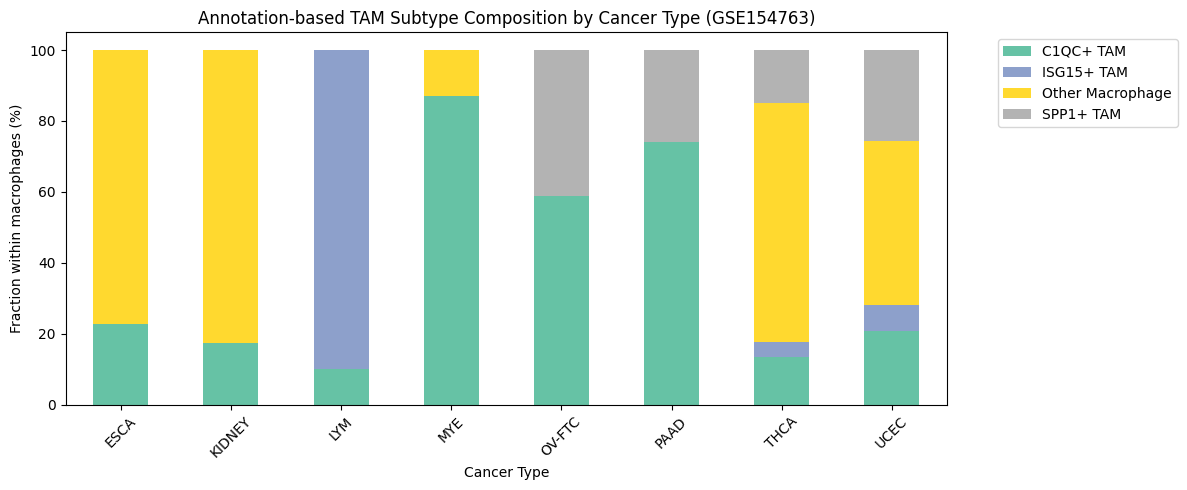

In [13]:
composition_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    colormap="Set2"
)

plt.title("Annotation-based TAM Subtype Composition by Cancer Type (GSE154763)")
plt.ylabel("Fraction within macrophages (%)")
plt.xlabel("Cancer Type")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 그래프 분석

Stacked bar plot을 통해 암종별 macrophage subtype composition의 차이를 시각적으로 확인하였다.

- LYM은 ISG15+ TAM 비율이 90.1%로 가장 높아, 다른 암종과 뚜렷하게 구분되는 패턴을 보였다.
- MYE와 PAAD는 C1QC+ TAM이 우세한 암종으로 나타났다.
- OV-FTC와 PAAD는 C1QC+ TAM과 SPP1+ TAM이 함께 관찰되는 암종이었다.
- ESCA와 KIDNEY는 Other Macrophage 비중이 높아, C1QC/SPP1/ISG15 strict subtype만으로는 macrophage 구성을 충분히 설명하기 어렵다.
- THCA와 UCEC는 C1QC+, SPP1+, ISG15+, Other Macrophage가 모두 관찰되어 상대적으로 heterogeneity가 큰 패턴을 보였다.

이 결과는 폐암 단일 데이터에서 관찰되지 않았던 ISG15+ macrophage population이 pan-cancer 데이터에서는 LYM을 중심으로 명확히 나타남을 보여준다. 따라서 ISG15+ TAM은 모든 암종에서 보편적으로 나타나는 subtype이라기보다, 암종 특이적으로 강하게 나타날 수 있는 macrophage state로 해석하는 것이 적절하다.

> 폐암 단일 데이터에서 뚜렷하지 않았던 ISG15+ macrophage population이 pan-cancer metadata에서는 LYM을 중심으로 명확히 관찰되었다.

따라서 ISG15+ TAM 부재가 모든 암종에 일반화되는 패턴은 아니며, 암종 특이적으로 나타날 수 있음을 확인하였다.

### 결과 분석

Annotation-based strict subtype 기준으로 암종별 macrophage composition을 비교한 결과, TAM subtype 구성은 암종마다 크게 달랐다. 본 비율은 전체 세포 대비 비율이 아니라, 각 암종의 macrophage population 내부에서 C1QC+ TAM, SPP1+ TAM, ISG15+ TAM, Other Macrophage가 차지하는 비율을 의미한다.

C1QC+ TAM은 MYE(86.9%), PAAD(74.2%), OV-FTC(58.7%)에서 우세하게 관찰되었다. 이는 해당 암종의 macrophage population에서 C1QC-labeled macrophage가 주요 subtype으로 존재함을 의미한다. 다만 본 분석은 clinical outcome을 포함하지 않으므로, C1QC+ TAM 우세를 직접적으로 예후와 연결해서 해석할 수는 없다.

ISG15+ TAM은 LYM에서 90.1%로 압도적으로 높았으며, THCA(4.3%)와 UCEC(7.6%)에서도 소량 관찰되었다. 이는 폐암 단일 데이터에서 뚜렷하게 보이지 않았던 ISG15+ macrophage population이 특정 암종, 특히 lymphoma에서 강하게 나타날 수 있음을 보여준다.

SPP1+ TAM은 OV-FTC(41.3%), PAAD(25.8%), UCEC(25.6%), THCA(15.0%)에서 관찰되었다. 반면 ESCA, KIDNEY, LYM, MYE에서는 MajorCluster 이름에 SPP1이 포함된 macrophage cluster가 없어 strict annotation 기준으로 SPP1+ TAM 비율이 0%로 나타났다. 단, 이 암종들의 Other Macrophage 내부에 SPP1-like expression pattern을 보이는 cluster가 존재할 가능성은 marker score 기반으로 별도 확인이 필요하다.

전체적으로 C1QC+ TAM과 SPP1+ TAM은 pan-cancer 수준에서 반복적으로 관찰되지만, 모든 암종의 macrophage heterogeneity를 두 subtype만으로 설명하기는 어렵다. 특히 LYM에서는 ISG15+ macrophage가 지배적이었고, ESCA/KIDNEY/THCA/UCEC에서는 Other Macrophage 비중이 높게 나타났다.

# 8. Annotation-based UpSet plot

UpSet plot은 암종별로 annotation-based strict TAM subtype label이 어떤 조합으로 존재하는지 확인하기 위한 시각화이다.

즉 각 암종에서 C1QC+ TAM, SPP1+ TAM, ISG15+ TAM label이 단독 또는 조합으로 나타나는지 본다.

이 분석은 marker gene expression 기반이 아니라 MajorCluster annotation 기반 presence 분석이다.

In [14]:
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

cancer_subtypes = {}

for cancer in adata_mac.obs["cancer"].unique():
    subset = adata_mac.obs[adata_mac.obs["cancer"] == cancer]
    subtypes = subset["tam_subtype"].unique().tolist()
    subtypes = [s for s in subtypes if s != "Other Macrophage"]
    cancer_subtypes[cancer] = subtypes

print(cancer_subtypes)

{'ESCA': ['C1QC+ TAM'], 'KIDNEY': ['C1QC+ TAM'], 'LYM': ['ISG15+ TAM', 'C1QC+ TAM'], 'MYE': ['C1QC+ TAM'], 'OV-FTC': ['C1QC+ TAM', 'SPP1+ TAM'], 'PAAD': ['SPP1+ TAM', 'C1QC+ TAM'], 'THCA': ['C1QC+ TAM', 'ISG15+ TAM', 'SPP1+ TAM'], 'UCEC': ['ISG15+ TAM', 'C1QC+ TAM', 'SPP1+ TAM']}


c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\upsetplot\data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(

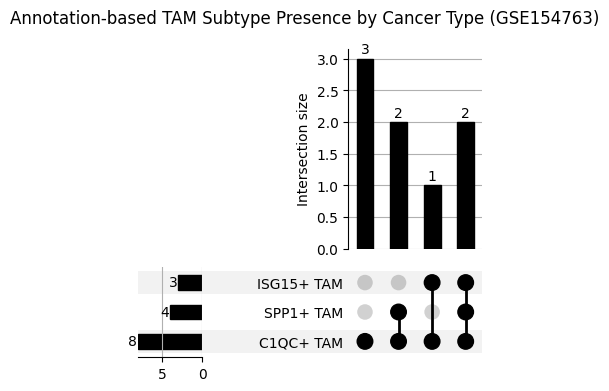

In [15]:
memberships = list(cancer_subtypes.values())
labels = list(cancer_subtypes.keys())

data = from_memberships(memberships, data=labels)

upset = UpSet(data, subset_size="count", show_counts=True)
upset.plot()

plt.suptitle("Annotation-based TAM Subtype Presence by Cancer Type (GSE154763)")
plt.tight_layout()
plt.show()

### UpSet plot 해석법

왼쪽 가로 막대(Set Size):
- C1QC+ TAM: 8개 암종 모두 존재
- SPP1+ TAM: 4개 암종
- ISG15+ TAM: 3개 암종
위쪽 세로 막대 + 아래 점 조합(Intersection):
- 점 하나만 채워진 것 -> 그 서브타입만 단독으로 있는 암종 수
- 점 여러개 연결된 것 -> 그 조합이 같이 있는 암종 수

### RESULT
C1QC+ TAM은 8개 암종 모두에서 관찰되었다.  
SPP1+ TAM은 OV-FTC, PAAD, THCA, UCEC에서 관찰되었다.  
ISG15+ TAM은 LYM, THCA, UCEC에서 관찰되었다.

C1QC+ TAM 단독 조합은 ESCA, KIDNEY, MYE에서 나타났고, C1QC+ TAM과 SPP1+ TAM 조합은 OV-FTC와 PAAD에서 나타났다. THCA와 UCEC는 C1QC+ TAM, SPP1+ TAM, ISG15+ TAM이 모두 관찰되었다.

# B. Marker score-based validation

Annotation-based strict subtype 분석은 기존 MajorCluster 이름에 의존한다.  
따라서 cluster 이름에는 C1QC/SPP1/ISG15가 없지만, marker expression상 특정 subtype과 유사한 cluster가 있을 수 있다.

이를 확인하기 위해 C1QC_score, SPP1_score, ISG15_score를 계산하여 기존 annotation과 marker expression 경향이 일치하는지 검증하였다.

# 9. Load inner AnnData for score calculation

Marker score 계산은 gene expression matrix를 직접 사용하므로, 모든 암종에 공통으로 존재하는 gene만 포함한 inner-joined AnnData를 사용하는 것이 더 안전하다.

In [16]:
adata_score = sc.read_h5ad(ALL_INNER_H5AD)

adata_mac_score = adata_score[
    adata_score.obs["MajorCluster"].str.contains("Macro", case=False, na=False)
].copy()

adata_mac_score.obs["tam_subtype"] = adata_mac_score.obs["MajorCluster"].apply(map_tam_subtype)

print(adata_mac_score)

AnnData object with n_obs × n_vars = 27247 × 11102
    obs: 'percent_mito', 'n_counts', 'percent_hsp', 'batch', 'cancer', 'patient', 'tissue', 'n_genes', 'MajorCluster', 'source', 'tech', 'UMAP1', 'UMAP2', 'tam_subtype'


# 10. Calculate marker scores

문자열 annotation만으로는 각각의 subtype들이 SPP1-like인지, C1QC-like인지 독립 state인지 알 수 없기 때문에 marker score을 계산하여 정량적 수치 결과로 확인한다.

In [17]:
c1qc_genes = ["C1QA", "C1QB", "C1QC", "APOC1"]
spp1_genes = ["SPP1", "GPNMB", "CTSD", "MRC1", "CD63"]
isg15_genes = ["ISG15", "CXCL10", "GBP1"]

def filter_genes(adata, genes):
    return [g for g in genes if g in adata.var_names]

marker_sets = {
    "C1QC_score": c1qc_genes,
    "SPP1_score": spp1_genes,
    "ISG15_score": isg15_genes,
}

for score_name, genes in marker_sets.items():
    selected_genes = filter_genes(adata_mac_score, genes)
    print(score_name, selected_genes)
    
    sc.tl.score_genes(
        adata_mac_score,
        gene_list=selected_genes,
        score_name=score_name
    )

C1QC_score ['C1QA', 'C1QB', 'C1QC', 'APOC1']
SPP1_score ['SPP1', 'GPNMB', 'CTSD', 'MRC1', 'CD63']
ISG15_score ['ISG15', 'CXCL10', 'GBP1']


### score_genes

>> marker 유전자 평균 발현에서 비슷한 발현 수준의 control gene평균을 뺀 값이기 때문에 0보다 작은 값이 나올 수 있다.

code에서 marker gene set이 기준(평균 값)인데 단순하게 `그 유전자들의 발현률 평균` 만 보는 것은 아니다.

gene set score
- 관심 marker gene들의 평균 발현량
- 비슷한 발현 수준을 가진 control gene 들의 평균 발현량

scanpy 공식 문서에서도 score_genes는 `주어진 gene set의 평균 발현에서 reference/control gene set의 평균 발현을 뺀 값` 이라고 설명되어있다. reference gene은 전체 gene pool에서 발현 수준 bin을 맞춰 무직위로 뽑는다.

### Q. 마이너스는 어떻게 나오는건가?

1. 예를 들어 SPP1_score를 계산할 때 gene set은 밑과 같다고 가정하자.  
`spp1_genes = ['SPP1', 'GPNMB', 'CTSD', 'MRC1', 'CD63']`  
2. 그러면 각 cell 마다 대략 이런 계산을 하게 된다.
SPP1_score
= mean (SPP1, GPNMB, CTSD, MRC1, CD63) - mean(control genes)
3. 그래서 값이 밑과 같이 나오게 된다.
- 양수 -> 이 marker set이 control gene 평균보다 높다
- 0근처 -> 특별히 높지 않다
- 음수 -> 이 marker set이 control gene 평균보다 낮다

즉, `마이너스 = 발현이 0` 이 아니다.
정확히는 비슷한 발현 수준의 배경 유전자들에 비해 marker set 발현이 낮다 라는 뜻이다.

# 11. MajorCluster-level score validation

MajorCluster별 marker score를 확인한 결과, C1QC로 annotation된 macrophage cluster는 C1QC_score가 높았고, SPP1 cluster는 SPP1_score가 높았으며, ISG15 cluster는 ISG15_score가 높았다.

따라서 기존 MajorCluster annotation은 marker score와 전반적으로 일치하였다.

다만 GPNMB, LYVE1, IL1B 등 일부 Other Macrophage cluster에서도 C1QC_score가 상대적으로 높게 나타나, strict annotation 기준으로는 Other로 유지하되 C1QC-like expression tendency가 있을 수 있음을 확인하였다.

In [18]:
score_summary = adata_mac_score.obs.groupby("MajorCluster")[
    ["C1QC_score", "SPP1_score", "ISG15_score"]
].mean()

display(score_summary.sort_values("SPP1_score", ascending=False))

C:\Users\82108\AppData\Local\Temp\ipykernel_17768\4140860066.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  score_summary = adata_mac_score.obs.groupby("MajorCluster")[


,C1QC_score,SPP1_score,ISG15_score
MajorCluster,,,
M07_Macro_C1QC,1.795645,0.639662,0.506533
M08_Macro_SPP1,0.159000,0.573843,-0.045795
M09_Macro_SPP1,-1.053476,0.526210,-0.116482
M10_Macro_SPP1,-1.119782,0.368626,0.072133
M09_Macro_C1QC,1.087558,0.287463,0.069298
M11_Macro_C1QC,1.164453,0.176441,-0.015457
M10_Macro_C1QC,0.914991,0.145975,0.267101
M10_Macro_GPNMB,1.157394,0.103374,-0.014524
M11_Macro_LYVE1,0.436404,-0.033545,-0.137800


# 12. Cancer-level score tendency

암종별 macrophage population의 평균 marker score를 계산하여, 각 암종에서 어떤 TAM marker program이 상대적으로 강한지 확인하였다.

In [19]:
score_by_cancer = adata_mac_score.obs.groupby("cancer")[
    ["C1QC_score", "SPP1_score", "ISG15_score"]
].mean()

display(score_by_cancer.round(3))

C:\Users\82108\AppData\Local\Temp\ipykernel_17768\1484464906.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  score_by_cancer = adata_mac_score.obs.groupby("cancer")[


,C1QC_score,SPP1_score,ISG15_score
cancer,,,
ESCA,-0.484,-0.201,0.121
KIDNEY,0.716,-0.162,-0.063
LYM,-0.683,-0.489,1.294
MYE,0.449,-0.153,0.122
OV-FTC,0.859,0.379,-0.006
PAAD,0.744,0.695,0.068
THCA,-0.583,-0.363,-0.001
UCEC,-0.601,-0.096,0.103


### Q. 각 암종의 macrophage population은 평균적으로 어떤 TAM marker program이 강한가?

C1QC: KIDNEY, OV-FTC, PAAD에서는 강하게 나타났지만 세가지 cell 중에서 음수로 측정된 것도 가장 많았다. 즉 특정 암종에 대하여 제한적인 발현량을 가지는 것 같다.  
SPP1: 가장 score가 높은 암이 PAAD로 0.695정도이다. Unknown으로 분류 된 암종들 중에 특별히 눈에 띌만한 결과는 아니다.  
ISG15: LYM만이 1점대 이상으로 높게 나타났다. 나머지는 거의 0.01대로 고르게 적게 분포한다.  

score avg만 본다면 cell-level의 분포가 보이지 않으니 boxplot이나 violin을 사용하여 추가 확인을 해보았다.  

# 13. Cancer-level score tendency

암종 별 subtype score violin을 나타내보았다.

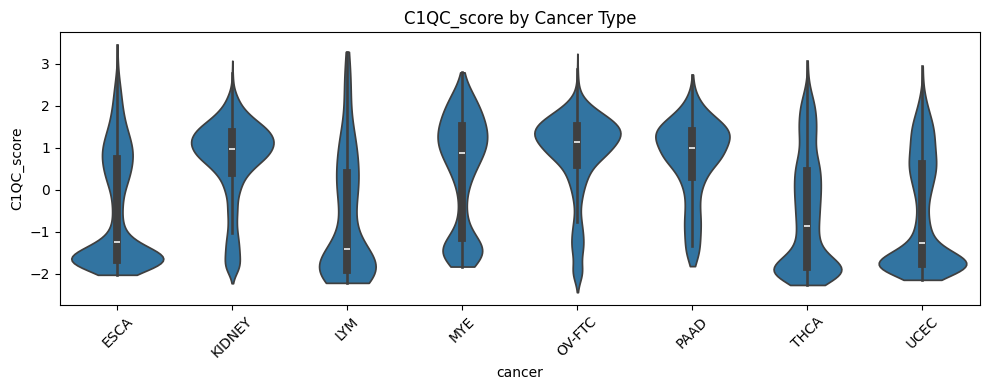

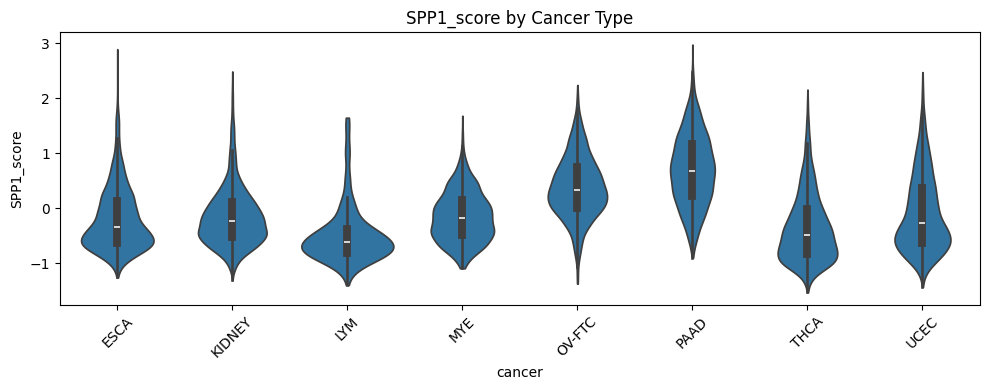

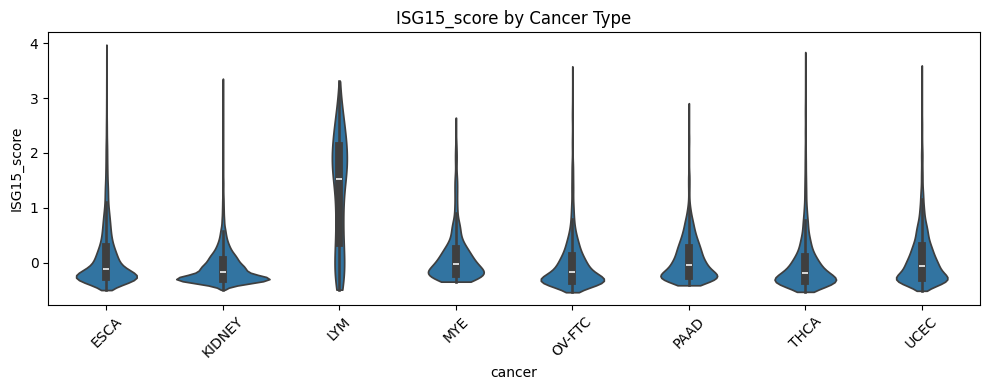

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

score_cols = ["C1QC_score", "SPP1_score", "ISG15_score"]

for score in score_cols:
    plt.figure(figsize=(10, 4))
    sns.violinplot(
        data=adata_mac_score.obs,
        x="cancer",
        y=score,
        inner="box",
        cut=0
    )
    plt.title(f"{score} by Cancer Type")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Optional: score-based marker program presence

이 분석은 암종별 평균 marker score가 0보다 큰 경우 해당 marker gene progra,이 존재한다고 보는  exploratory analysis이다.  

단 threshold 기준에 따라 결과가 달라질 수 있으므로 annotation-based UpSet과 동일한 수준의 확정적 subtype label로 해석하지 않는다.

In [21]:
score_presence = score_by_cancer > 0
display(score_presence)

,C1QC_score,SPP1_score,ISG15_score
cancer,,,
ESCA,False,False,True
KIDNEY,True,False,False
LYM,False,False,True
MYE,True,False,True
OV-FTC,True,True,False
PAAD,True,True,True
THCA,False,False,False
UCEC,False,False,True


{'ESCA': ['ISG15_score+'], 'KIDNEY': ['C1QC_score+'], 'LYM': ['ISG15_score+'], 'MYE': ['C1QC_score+', 'ISG15_score+'], 'OV-FTC': ['C1QC_score+', 'SPP1_score+'], 'PAAD': ['C1QC_score+', 'SPP1_score+', 'ISG15_score+'], 'THCA': [], 'UCEC': ['ISG15_score+']}


c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\upsetplot\data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(

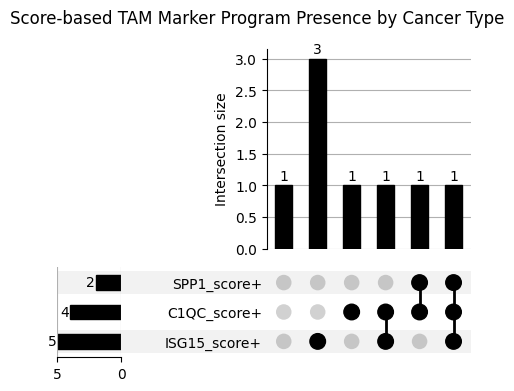

In [22]:
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

score_name_map = {
    "C1QC_score": "C1QC_score+",
    "SPP1_score": "SPP1_score+",
    "ISG15_score": "ISG15_score+",
}

score_memberships = {}

for cancer, row in score_presence.iterrows():
    present_scores = [
        score_name_map[col]
        for col in score_presence.columns
        if row[col]
    ]
    score_memberships[cancer] = present_scores

print(score_memberships)

data = from_memberships(
    list(score_memberships.values()),
    data=list(score_memberships.keys())
)

upset = UpSet(data, subset_size="count", show_counts=True)
upset.plot()

plt.suptitle("Score-based TAM Marker Program Presence by Cancer Type")
plt.tight_layout()
plt.show()

# Save Result

결과를 저장한다.

In [ ]:
adata_mac.write_h5ad(ALL_MAC_H5AD)
adata_mac_score.write_h5ad(ALL_MAC_SCORE_H5AD)

print(adata_mac)
print(adata_mac_score)

print(f'저장 완료: {ALL_MAC_H5AD}')
# print(f'저장 완료: {ALL_MAC_SCORE_H5AD}')

AnnData object with n_obs × n_vars = 27247 × 18486
    obs: 'percent_mito', 'n_counts', 'percent_hsp', 'barcode', 'batch', 'library_id', 'cancer', 'patient', 'tissue', 'n_genes', 'MajorCluster', 'source', 'tech', 'UMAP1', 'UMAP2', 'tam_subtype'
AnnData object with n_obs × n_vars = 27247 × 11102
    obs: 'percent_mito', 'n_counts', 'percent_hsp', 'batch', 'cancer', 'patient', 'tissue', 'n_genes', 'MajorCluster', 'source', 'tech', 'UMAP1', 'UMAP2', 'tam_subtype', 'C1QC_score', 'SPP1_score', 'ISG15_score'
저장 완료: dataset\GSE154763_all_mac.h5ad
